# Organoid quality and blacklist candidate review

**Role:** Analysis.

Inspect validation errors and measured/predicted curvature on individual organoids using a restored model. Rank candidates for manual data-quality review, inspect their meshes, and export a draft list if requested. A poorly predicted organoid is not automatically bad data. The notebook never changes training splits or applies a new blacklist, and it does not retrain outcome-selected models.

Select model depth and one saved fold in the settings cell. The interactive review panel filters fixed validation MSE ranks and sphericity, previews candidate metadata, and displays ground-truth and predicted curvature side by side on the selected mesh. All organoids in that saved validation fold can be reviewed; TOP_N limits only the introductory table and optional draft export.


In [1]:
from pathlib import Path
import sys
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/models/gnn.py").is_file())  # Locate the repository from the notebook’s working directory.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
ROOT = PROJECT_ROOT  # Repository root used to resolve data and result paths.

## Analysis settings

Choose the input run or cached report and all analysis options here before model loading, inference or plotting. Derived paths and model-dependent defaults are resolved in the following cells; each checkpoint restores its saved data and transformations.

In [2]:
import numpy as np
import torch

# Sampling and plot selection
TRAINING_NOTEBOOK = 'gin_depth_training'  # Folder under training_results containing the saved run.
TOP_N = 12  # Number of highest-error organoids displayed for review.
CANDIDATE = None  # Initial organoid ID if it passes the widget filters; None selects the highest eligible MSE.

# Input runs, data and destinations
TRAINING_RUN = None  # Set a run directory name; None selects only if exactly one exists.

# Model selection
MODEL_DEPTH = 4  # Message-passing layers; choose a depth saved in the training run.
MODEL_FOLD = 0  # Load exactly one saved fold, never combine independent embedding spaces.
MODEL_NAME = 'gin'  # gin or film; None requires a unique model family among the matches.
MODEL_SEED = None  # None requires a unique saved seed at this depth/fold; otherwise specify the seed.
HIDDEN_DIM = None  # None requires a unique saved width; otherwise specify it.
MODEL_KEY = None  # Optional exact checkpoint key overriding the depth/fold/family/seed/width selectors.

# Inference resources
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'  # Use CUDA when available, otherwise CPU.

# Execution and display
EXPORT_DRAFT = False  # Export review candidates without changing the blacklist.

# Interactive candidate selection
MSE_RANK_RANGE = None  # Inclusive global MSE ranks (1 = worst); None initially shows all validation organoids.
SPHERICITY_RANGE = None  # Initial inclusive Q interval; None spans all finite values in the saved cohort.
INCLUDE_MISSING_SPHERICITY = False  # Allow organoids with missing/invalid area or volume into the selector.


## Select one saved depth and fold

Choose `MODEL_DEPTH` and `MODEL_FOLD` near the top, with family/seed/width selectors when needed. `MODEL_KEY` is an optional exact override. The resolved checkpoint is printed before inference, and only its saved validation cohort is ranked. Independent fold models are not pooled. Draft exports remain separate from the dataset blacklist.


In [3]:
import json, copy
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from src.artifacts.runs import AnalysisRun
from src.analysis.metrics.evaluation import prediction_table
from src.artifacts.paths import resolve_training_run
RUN_DIR = resolve_training_run(ROOT, TRAINING_NOTEBOOK, TRAINING_RUN)  # Also accepts an explicit historical path.
run = AnalysisRun(RUN_DIR)
display(run.records)

# Saved model selection: one depth, one fold and one checkpoint.
if MODEL_KEY is None:
    if not isinstance(MODEL_DEPTH,int) or isinstance(MODEL_DEPTH,bool) or MODEL_DEPTH<0:
        raise ValueError('MODEL_DEPTH must be a nonnegative integer.')
    if not isinstance(MODEL_FOLD,int) or isinstance(MODEL_FOLD,bool) or MODEL_FOLD<0:
        raise ValueError('MODEL_FOLD must be a nonnegative integer.')
    candidates = run.records[(run.records.depth==MODEL_DEPTH)&(run.records.fold==MODEL_FOLD)].copy()
    for column,value in [('name',MODEL_NAME),('seed',MODEL_SEED),('hidden_dim',HIDDEN_DIM)]:
        if value is None:
            continue
        if column in candidates:
            candidates = candidates[candidates[column]==value]
        elif column=='hidden_dim' and run.legacy is not None:
            if run.legacy.settings['HIDDEN_DIM']!=value:
                candidates = candidates.iloc[:0]
        else:
            raise ValueError(f'The saved catalog lacks selection field {column}.')
    if len(candidates)!=1:
        raise ValueError(f'Select exactly one checkpoint at depth={MODEL_DEPTH}, fold={MODEL_FOLD}. '
            f'Matches: {candidates.key.tolist()}. Adjust MODEL_NAME, MODEL_SEED or HIDDEN_DIM, '
            'or provide MODEL_KEY from the displayed catalog.')
    selected_record = candidates.iloc[0]
else:
    candidates = run.records[run.records.key==MODEL_KEY]
    if len(candidates)!=1:
        raise ValueError(f'MODEL_KEY must identify one saved checkpoint: {MODEL_KEY}')
    selected_record = candidates.iloc[0]
# Do not overwrite MODEL_KEY: changing MODEL_DEPTH then rerunning this cell must
# reselect using the controls rather than accidentally pinning the old key.
SELECTED_MODEL_KEY = str(selected_record.key)
print(f'Loaded checkpoint: {SELECTED_MODEL_KEY}')
print(f"Model: {selected_record['name']}; depth: {selected_record.depth}; fold: {selected_record.fold}; seed: {selected_record.seed}")
if int(selected_record.depth)==0:
    print('Depth 0 has no neighbor aggregation. Repeated fate inputs can yield identical local embeddings.')

# Inference resources
selection = run.select(SELECTED_MODEL_KEY, device=DEVICE)
model = selection['model']
marker_names = selection['marker_names']
g_train, g_val = selection['groups']['train'], selection['groups']['val']
OUTPUT_DIR = RUN_DIR/'analysis'/'cohort_review'/SELECTED_MODEL_KEY  # Directory for this analysis’s tables and figures.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


print(f'Reviewing {len(g_val)} validation organoids from fold {selected_record.fold}; model depth {selected_record.depth}.')


,key,name,subset,signal,depth,hidden_dim,fold,seed,bundle,input_bundle
0,gin_all_intact_d0_h128_f0_s42,gin,all,intact,0,128,0,42,models/gin_all_intact_d0_h128_f0_s42,inputs/fold_0_all_intact
1,gin_all_intact_d1_h128_f0_s42,gin,all,intact,1,128,0,42,models/gin_all_intact_d1_h128_f0_s42,inputs/fold_0_all_intact
2,gin_all_intact_d2_h128_f0_s42,gin,all,intact,2,128,0,42,models/gin_all_intact_d2_h128_f0_s42,inputs/fold_0_all_intact
3,gin_all_intact_d3_h128_f0_s42,gin,all,intact,3,128,0,42,models/gin_all_intact_d3_h128_f0_s42,inputs/fold_0_all_intact
4,gin_all_intact_d4_h128_f0_s42,gin,all,intact,4,128,0,42,models/gin_all_intact_d4_h128_f0_s42,inputs/fold_0_all_intact
5,gin_all_intact_d0_h128_f1_s42,gin,all,intact,0,128,1,42,models/gin_all_intact_d0_h128_f1_s42,inputs/fold_1_all_intact
6,gin_all_intact_d1_h128_f1_s42,gin,all,intact,1,128,1,42,models/gin_all_intact_d1_h128_f1_s42,inputs/fold_1_all_intact
7,gin_all_intact_d2_h128_f1_s42,gin,all,intact,2,128,1,42,models/gin_all_intact_d2_h128_f1_s42,inputs/fold_1_all_intact
8,gin_all_intact_d3_h128_f1_s42,gin,all,intact,3,128,1,42,models/gin_all_intact_d3_h128_f1_s42,inputs/fold_1_all_intact
9,gin_all_intact_d4_h128_f1_s42,gin,all,intact,4,128,1,42,models/gin_all_intact_d4_h128_f1_s42,inputs/fold_1_all_intact


Loaded checkpoint: gin_all_intact_d4_h128_f0_s42
Model: gin; depth: 4; fold: 0; seed: 42


/home/fmoller/miniforge3/envs/organoid-gnn/lib/python3.11/site-packages/torch/cuda/__init__.py:829: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


Reviewing 174 validation organoids from fold 0; model depth 4.


## Rank validation organoids

Compute MSE and bias in physical curvature units, with any saved baseline offset restored. Rank 1 is the highest validation MSE; ranks are fixed before widget filtering. Add collection metadata and the same sphericity definition used by the training filter: **Q = 36π V²/A³**, where a sphere has Q=1. Missing or invalid geometry yields a missing Q, not a guessed value. Selection here only affects review and does not change the saved cohort.


,mse_rank,n_cells,mse,bias,max_absolute_error,sphericity,surface_area,volume,timepoint
organoid_str,,,,,,,,,
organoid_day4p5_B05_32,1,520,0.006671,0.004881,0.211993,0.476963,483.184359,689.740403,day4p5
organoid_day4p5-more_C05_146,2,387,0.006157,0.014504,0.251063,0.649351,253.689445,306.173270,day4p5-more
organoid_day4_A06_65,3,330,0.005969,0.007923,0.223930,0.515054,360.120399,461.181422,day4
organoid_day4_A03_13,4,271,0.005181,0.000294,0.214081,0.534604,238.680313,253.521595,day4
organoid_day4p5_B06_23,5,235,0.005112,0.002542,0.203709,0.657631,250.297017,301.959431,day4p5
organoid_day4p5-more_C02_16,6,494,0.004952,0.029372,0.214377,0.637023,350.868941,493.251913,day4p5-more
organoid_day4p5-more_C05_71,7,897,0.004949,-0.007053,0.206483,0.399215,440.840584,549.920220,day4p5-more
organoid_day4_A02_27,8,556,0.004884,0.003751,0.269268,0.541085,356.751304,466.074107,day4
organoid_day4p5-more_C05_158,9,1096,0.004782,0.021657,0.252638,0.451593,459.022420,621.438386,day4p5-more


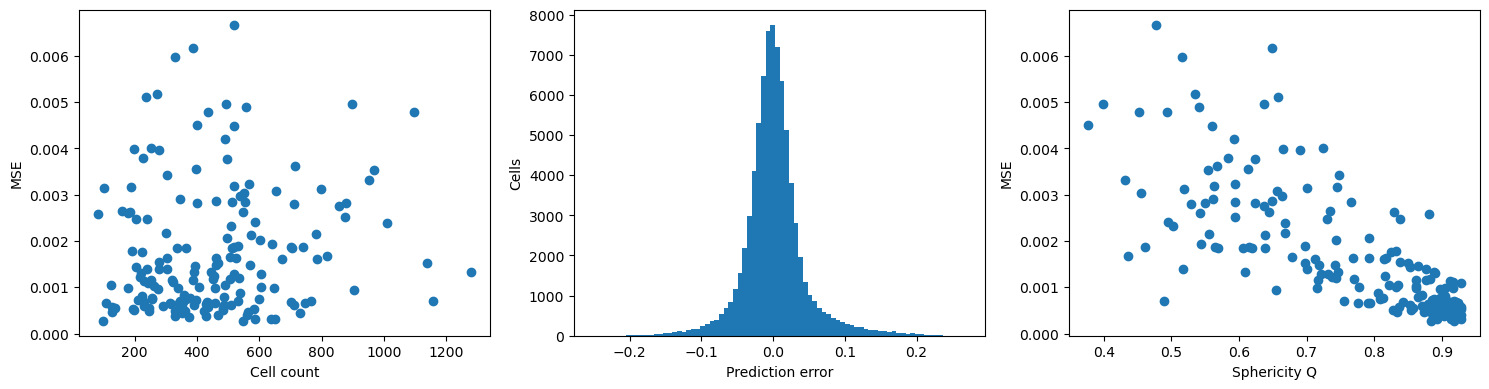

In [4]:
cells=prediction_table(selection,device=DEVICE)
ranked=cells.groupby('organoid_str').agg(n_cells=('node','size'),mse=('squared_error','mean'),
    bias=('error','mean'),max_absolute_error=('error',lambda x:np.abs(x).max())).sort_values('mse',ascending=False,kind='stable')
from src.data.metadata import get_graph_metadata_value

def metadata_scalar(graph,key):
    value = get_graph_metadata_value(graph,key,default=None)
    if value is None:
        return np.nan
    array = np.asarray(value).reshape(-1)
    return float(array[0]) if array.size==1 else np.nan

metadata_rows = []
for organoid in ranked.index:
    raw = selection['raw_graphs'][organoid]
    area = metadata_scalar(raw,'total_surface_area')
    volume = metadata_scalar(raw,'total_volume')
    q = 36*np.pi*volume**2/area**3 if np.isfinite(area) and np.isfinite(volume) and area>0 and volume>0 else np.nan
    metadata_rows.append(dict(organoid_str=organoid,sphericity=q,surface_area=area,volume=volume,
        timepoint=get_graph_metadata_value(raw,'timepoint',default='unknown')))
ranked = ranked.join(pd.DataFrame(metadata_rows).set_index('organoid_str'))
ranked.insert(0,'mse_rank',np.arange(1,len(ranked)+1))
display(ranked.head(TOP_N))
ranked.to_csv(OUTPUT_DIR/'organoid_diagnostics.csv')
fig,axes=plt.subplots(1,3,figsize=(15,4))
axes[0].scatter(ranked.n_cells,ranked.mse);axes[0].set(xlabel='Cell count',ylabel='MSE')
axes[1].hist(cells.error,bins=80);axes[1].set(xlabel='Prediction error',ylabel='Cells')
axes[2].scatter(ranked.sphericity,ranked.mse);axes[2].set(xlabel='Sphericity Q',ylabel='MSE')
plt.tight_layout();plt.show()

## Interactive candidate mesh inspection

Choose an inclusive **global MSE-rank interval** and **sphericity Q interval**, then choose an organoid from the filtered dropdown. Its label includes rank, MSE and Q. The metadata preview updates immediately; click **Display mesh** to load the selected organoid and show ground truth on the left and model prediction on the right with a shared color scale. Predictions were computed above and are not recomputed when browsing.

Rank 1 remains the worst MSE in the full validation fold even after filtering. Missing-Q organoids can be included explicitly. If no candidates match, the selector and display button are disabled and the previous mesh is cleared. Missing mesh files or ownership metadata are reported for the selected organoid; the widget never substitutes another one. This view requires Jupyter widget support (`ipywidgets`).


In [ ]:
import ipywidgets as widgets
from IPython.display import clear_output
from src.plotting.mesh_plots import project_node_quantities_to_mesh, plot_projected_true_vs_pred


def review_candidates(table,rank_range,sphericity_range,include_missing=False):
    """Filter fixed global MSE ranks and inclusive Q bounds without reranking."""
    lo_rank,hi_rank = rank_range
    lo_q,hi_q = sphericity_range
    if lo_rank>hi_rank or lo_q>hi_q:
        raise ValueError('Range lower bounds must not exceed upper bounds.')
    q = table.sphericity
    eligible_q = q.between(lo_q,hi_q)&np.isfinite(q)
    if include_missing:
        eligible_q |= ~np.isfinite(q)
    return table[table.mse_rank.between(lo_rank,hi_rank)&eligible_q].sort_values('mse_rank')


def build_candidate_browser(table,cell_predictions,raw_graphs,*,rank_range=None,sphericity_range=None,
                            include_missing=False,initial_candidate=None):
    """Notebook-specific review UI: selection never modifies data or reruns inference."""
    if table.empty:
        raise ValueError('No validation organoids to inspect.')
    finite_q = table.loc[np.isfinite(table.sphericity),'sphericity']
    q_min = min(0.,float(finite_q.min())) if len(finite_q) else 0.
    q_max = max(1.,float(finite_q.max())) if len(finite_q) else 1.
    rank_range = (1,len(table)) if rank_range is None else tuple(rank_range)
    sphericity_range = (q_min,q_max) if sphericity_range is None else tuple(sphericity_range)
    if len(rank_range)!=2 or not 1<=rank_range[0]<=rank_range[1]<=len(table):
        raise ValueError(f'MSE_RANK_RANGE must lie between 1 and {len(table)} inclusive.')
    if len(sphericity_range)!=2 or not np.isfinite(sphericity_range).all() or sphericity_range[0]>sphericity_range[1]:
        raise ValueError('SPHERICITY_RANGE must contain two ordered finite values.')
    q_min,q_max = min(q_min,sphericity_range[0]),max(q_max,sphericity_range[1])
    style = {'description_width':'initial'}
    ranks = widgets.IntRangeSlider(value=rank_range,min=1,max=len(table),step=1,
        description='Global MSE ranks',continuous_update=False,style=style,layout=widgets.Layout(width='95%'))
    sphericity = widgets.FloatRangeSlider(value=sphericity_range,min=q_min,max=q_max,step=.001,
        readout_format='.3f',description='Sphericity Q',continuous_update=False,style=style,
        layout=widgets.Layout(width='95%'))
    missing = widgets.Checkbox(value=include_missing,description='Include missing sphericity')
    organoid = widgets.Dropdown(options=[],description='Organoid',style=style,layout=widgets.Layout(width='95%'))
    show_mesh = widgets.Button(description='Display mesh',button_style='primary')
    status = widgets.HTML()
    preview,mesh_output = widgets.Output(),widgets.Output()
    state = {'updating':False}

    def preview_selection(change=None):
        if state['updating']:
            return
        mesh_output.clear_output(wait=False)
        with preview:
            clear_output(wait=True)
            if organoid.value is not None:
                display(table.loc[[organoid.value]])

    def update_options(change=None):
        eligible = review_candidates(table,ranks.value,sphericity.value,missing.value)
        prior = organoid.value if organoid.value is not None else initial_candidate
        options = [(f"#{int(row.mse_rank)} | MSE {row.mse:.4g} | Q {row.sphericity:.3f} | {name}",name)
                   for name,row in eligible.iterrows()]
        state['updating'] = True
        try:
            organoid.options = options
            organoid.value = prior if prior in eligible.index else (options[0][1] if options else None)
            organoid.disabled = show_mesh.disabled = not bool(options)
        finally:
            state['updating'] = False
        status.value = (f'{len(eligible)} / {len(table)} validation organoids match. Rank 1 = highest MSE.'
                        if len(eligible) else 'No organoids match. Widen the rank/Q ranges or include missing sphericity.')
        preview_selection()

    def render_selected(button=None):
        name = organoid.value
        if name is None:
            return
        with mesh_output:
            clear_output(wait=True)
            try:
                frame = cell_predictions[cell_predictions.organoid_str==name].sort_values('node')
                raw = raw_graphs[name]
                if len(frame)!=len(raw.x) or not np.array_equal(frame.node,np.arange(len(raw.x))):
                    raise ValueError('Prediction rows do not align with the selected organoid nodes.')
                projection = project_node_quantities_to_mesh(raw,node_true=frame.y_true.to_numpy(),
                    node_pred=frame.y_pred.to_numpy())
                row = table.loc[name]
                figure = plot_projected_true_vs_pred(projection,true_title='Ground truth curvature',
                    pred_title='Predicted curvature',title=f'{name} | MSE rank {int(row.mse_rank)} | MSE {row.mse:.4g} | Q {row.sphericity:.3f}')
                display(figure)
            except Exception as exc:
                print(f'Cannot display mesh for {name}: {type(exc).__name__}: {exc}')

    for control in (ranks,sphericity,missing):
        control.observe(update_options,names='value')
    organoid.observe(preview_selection,names='value')
    show_mesh.on_click(render_selected)
    update_options()
    browser = widgets.VBox([ranks,sphericity,missing,status,organoid,preview,show_mesh,mesh_output])
    return browser,dict(rank=ranks,sphericity=sphericity,include_missing=missing,
                        organoid=organoid,show_mesh=show_mesh,status=status)

candidate_browser,candidate_controls = build_candidate_browser(ranked,cells,selection['raw_graphs'],
    rank_range=MSE_RANK_RANGE,sphericity_range=SPHERICITY_RANGE,
    include_missing=INCLUDE_MISSING_SPHERICITY,initial_candidate=CANDIDATE)
display(candidate_browser)


## Export a review draft

Save candidate IDs and metrics for review only. This is not an approved exclusion list and is not written into training data.

In [6]:
if EXPORT_DRAFT:
    ranked.head(TOP_N).to_csv(OUTPUT_DIR/'blacklist_candidates_review_only.csv')